In [1]:
# load data

import pandas as pd

df = pd.read_csv("../outputs/sample_size.csv")

In [ ]:
summary = (
    df.groupby("n_samples")
    .agg(
        mean_r2 = ("r2", "mean"),
        sd_r2 = ("r2", "std"),
        mean_mse=("mse", "mean"),
        sd_mse=("mse", "std"),
    )
    .reset_index()
)

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [3]:
summary

,n_samples,mean_r2,sd_r2,mean_mse,sd_mse
0,1,-1.405153,2.400143,0.913450,0.911548
1,2,-1.044871,1.475007,0.776619,0.560191
2,4,-0.728426,0.846163,0.656437,0.321363
3,6,-0.644528,0.589129,0.624574,0.223745
4,10,-0.210092,0.381286,0.459580,0.144808
5,15,0.050027,0.204609,0.360789,0.077708
6,23,0.158207,0.165505,0.319704,0.062857
7,37,0.269824,0.118853,0.277313,0.045139
8,58,0.294710,0.071718,0.267861,0.027238
9,91,0.341386,0.060441,0.250134,0.022955


Text(0, 0.5, 'Mean MSE')

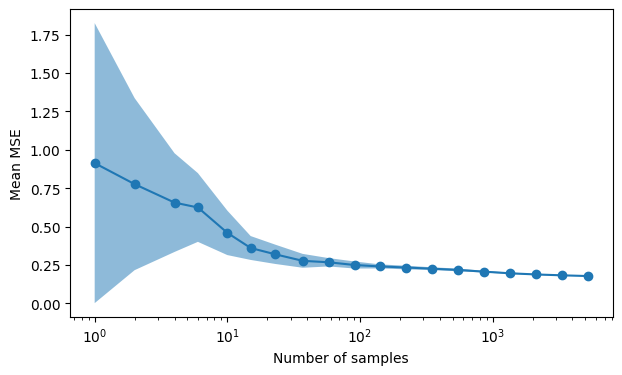

In [4]:
import matplotlib.pyplot as plt

x = summary['n_samples']
y = summary['mean_mse']
std = summary['sd_mse']

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x, y, marker='o')
ax.fill_between(x, y - std, y + std, alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('Number of samples')
ax.set_ylabel('Mean MSE')

In [5]:
def power_law(n, C, alpha, epsilon):
    return C* n **(-alpha) + epsilon

In [6]:
from scipy.optimize import curve_fit

k = summary["n_samples"].values
mse = summary["mean_mse"].values

p0 = [
    max(mse) - min(mse),
    0.5,
    min(mse)
]

params, _ = curve_fit(power_law, k, mse, p0=p0, maxfev=10000)

C_hat, alpha_hat, epsilon_hat = params

Text(0, 0.5, 'Mean MSE')

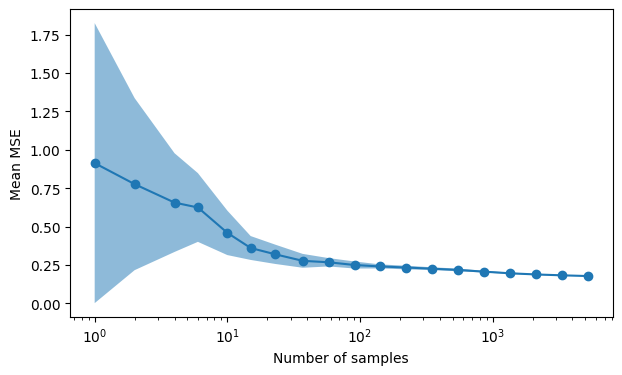

In [7]:
import matplotlib.pyplot as plt

x = summary['n_samples']
y = summary['mean_mse']
std = summary['sd_mse']

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x, y, marker='o')
ax.fill_between(x, y - std, y + std, alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('Number of samples')
ax.set_ylabel('Mean MSE')

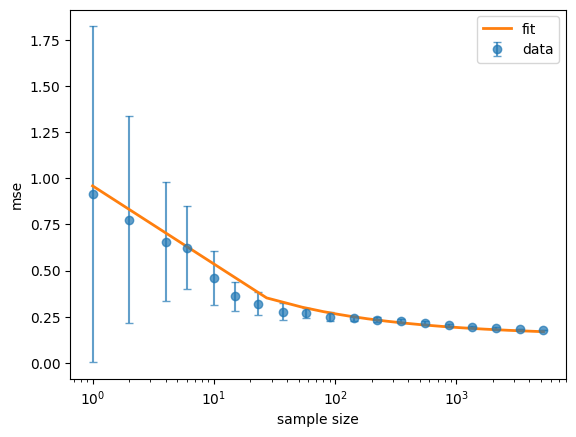

In [8]:
import numpy as np
import matplotlib.pyplot as plt

n_smooth = np.linspace(min(k), max(k), 200)


plt.errorbar(
    k,
    mse,
    yerr=std,
    fmt='o',
    capsize=3,
    alpha=0.7,
    label="data"
)

plt.plot(
    n_smooth,
    power_law(n_smooth, *params),
    lw=2,
    label="fit"
)

plt.xscale("log")
plt.xlabel("sample size")
plt.ylabel("mse")
plt.legend()
plt.show()

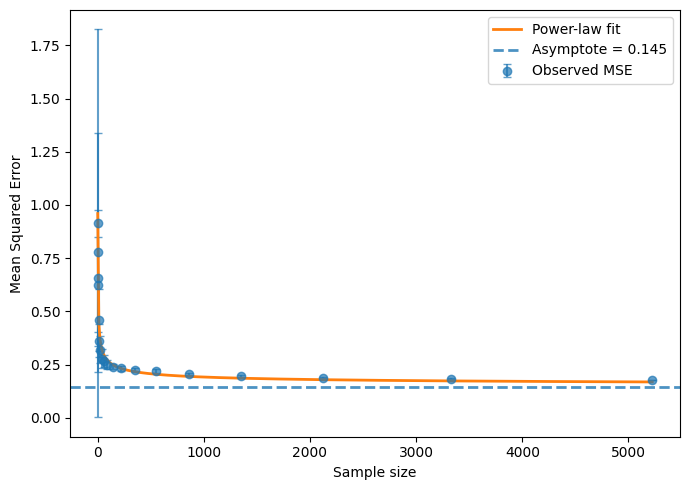

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# asymptote parameter
c = params[2]  # adjust index if your parameterisation differs

n_smooth = np.linspace(min(k), max(k), 500)

plt.figure(figsize=(7,5))

plt.errorbar(
    k,
    mse,
    yerr=std,
    fmt='o',
    capsize=3,
    alpha=0.7,
    label="Observed MSE"
)

plt.plot(
    n_smooth,
    power_law(n_smooth, *params),
    lw=2,
    label="Power-law fit"
)

plt.axhline(
    c,
    ls="--",
    lw=2,
    alpha=0.8,
    label=fr"Asymptote = {c:.3f}"
)


plt.xlabel("Sample size")
plt.ylabel("Mean Squared Error")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
print(params)

[0.81445409 0.41519535 0.14491538]


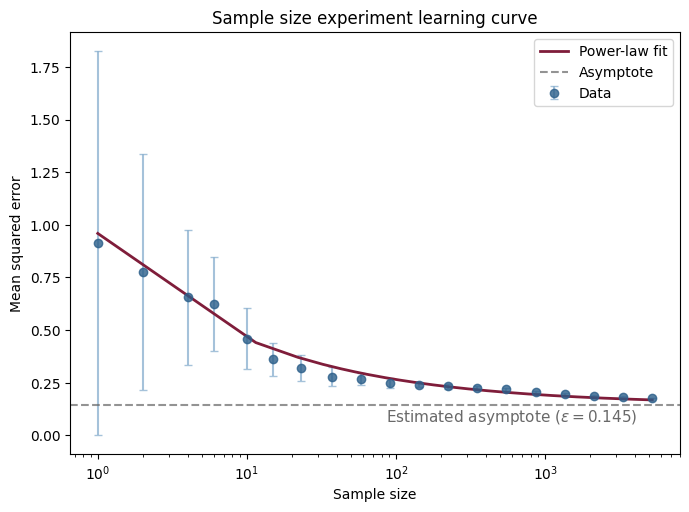

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def power_law(n, C, alpha, epsilon):
    return C * n**(-alpha) + epsilon

k = summary["n_samples"].values
mse = summary["mean_mse"].values

p0 = [
    max(mse) - min(mse),
    0.5,
    min(mse)
]

params, _ = curve_fit(power_law, k, mse, p0=p0, maxfev=10000)
C_hat, alpha_hat, epsilon_hat = params

n_smooth = np.linspace(min(k), max(k), 500)

darkrose = "#A23052"
fit_colour = "#7F1D3A"
asymptote_colour = "#666666"
data_colour = "#2C5F8A"
error_colour = "#8FB3D1"


fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    k,
    mse,
    yerr=std,
    fmt='o',
    capsize=3,
    alpha=0.8,
    label="Data",
    color = data_colour,
    ecolor= error_colour
)

ax.plot(
    n_smooth,
    power_law(n_smooth, *params),
    lw=2,
    label=fr"Power-law fit",
    color = fit_colour
)

ax.axhline(
    epsilon_hat,
    ls="--",
    lw=1.5,
    label=fr"Asymptote",
    alpha = 0.7,
    color = asymptote_colour
)

plt.text(
    max(k)*0.8,
    epsilon_hat - 0.015,
    fr'Estimated asymptote ($\epsilon={epsilon_hat:.3f}$)',
    ha='right',
    va='top',
    fontsize=11,
    color='dimgray'
)

ax.set_xscale("log")
ax.set_xlabel("Sample size")
ax.set_ylabel("Mean squared error")
ax.legend()
plt.tight_layout()
plt.title('Sample size experiment learning curve')
plt.savefig('../outputs/figures/sample_size.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [12]:
# fit something else ?
def shifted_power_law(n, C, alpha, epsilon, d):
    return C * (n + d) ** (-alpha) + epsilon

# optional weighting so large-n points matter more
weights = 1 / np.sqrt(k)

# initial guesses help optimization a lot
p0_power = [1.0, 0.5, 0.18]
p0_shift = [1.0, 0.5, 0.18, 10.0]
p0_exp = [0.25, 0.001, 0.18]

params_shift, _ = curve_fit(
    shifted_power_law,
    k,
    mse,
    p0=p0_shift,
    sigma=weights,
    absolute_sigma=False,
    maxfev=10000
)

/tmp/ipykernel_1823506/3570977730.py:3: RuntimeWarning: invalid value encountered in power
  return C * (n + d) ** (-alpha) + epsilon


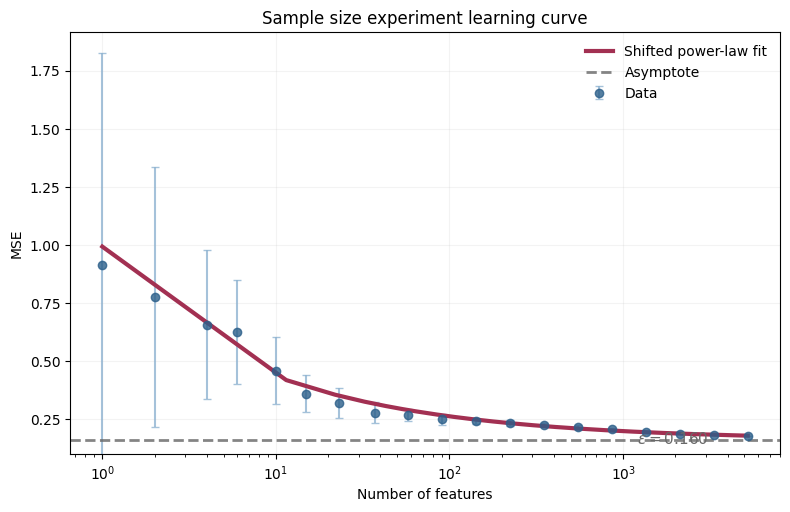

In [14]:

# choose the model you want to present
# for example: shifted power law
y_fit = shifted_power_law(n_smooth, *params_shift)

# asymptote for shifted power law
# adjust index if your parameter order differs
epsilon_hat = params_shift[2]

fig, ax = plt.subplots(figsize=(8, 5))

data_colour = "#2C5F8A"
error_colour = "#8FB3D1"

ax.errorbar(
    k,
    mse,
    yerr=std,
    fmt='o',
    capsize=3,
    alpha=0.8,
    label="Data",
    color = data_colour,
    ecolor= error_colour
)

ax.plot(
    n_smooth,
    y_fit,
    color="#A23052",
    lw=3,
    label="Shifted power-law fit"
)

ax.axhline(
    epsilon_hat,
    color="#666666",
    ls="--",
    lw=2,
    alpha=0.8,
    label = "Asymptote"
)

plt.text(
    1200,
    epsilon_hat - 0.013,
    fr'$\epsilon={epsilon_hat:.3f}$',
    fontsize=11,
    color='dimgray'
)

ax.set_xscale("log")
ax.set_xlabel("Number of features")
ax.set_ylabel("MSE")
ax.set_ylim(0.1)
ax.legend(frameon=False)
ax.grid(alpha=0.15)
fig.tight_layout()
plt.title('Sample size experiment learning curve')
plt.savefig('../outputs/figures/sample_size.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [14]:
params_shift

array([0.81744782, 0.45620627, 0.18821127, 0.27044566])